In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_training_log(log_str):
    """Parses the training log string into a pandas DataFrame."""
    pattern = r"Epoch \[(\d+)/\d+\] \| Train Loss: ([\d\.]+) \| Val Loss: ([\d\.]+)"
    matches = re.findall(pattern, log_str)
    if not matches:
        return None
    df = pd.DataFrame(matches, columns=["Epoch", "Train Loss", "Val Loss"])
    df = df.astype(float)
    df["Epoch"] = df["Epoch"].astype(int)
    return df

def plot_training_results(logs_dict, save_path="loss_comparison.png"):
    """
    Plots training and validation losses from a dictionary of logs.
    
    Args:
        logs_dict (dict): Keys are model names, values are log strings.
        save_path (str): File name to save the plot.
    """
    plt.figure(figsize=(6, 4))
    num_models = len(logs_dict)
    
    # Use standard color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, (model_name, log_str) in enumerate(logs_dict.items()):
        df = parse_training_log(log_str)
        if df is None:
            continue
            
        color = colors[i % len(colors)]
        if num_models == 1:
            color = 'red'
        
        # Determine legend labels
        if num_models == 1:
            train_label, val_label = "Train", "Val"
        else:
            train_label, val_label = f"$d={model_name}$ (Train)", f"$d={model_name}$ (Val)"
            
        # Plot Train Loss (Solid line)
        plt.plot(df["Epoch"], df["Train Loss"], 
                 label=train_label, color=color, linestyle='-', marker='o', markersize=3)
        
        # Plot Val Loss (Dashed line)
        plt.plot(df["Epoch"], df["Val Loss"], 
                 label=val_label, color=color, linestyle='--', marker='x', markersize=4)

    # plt.title("Model Training Progress: Train vs Validation Loss")
    plt.xlabel("Epoch", fontsize=13, fontweight='bold')
    plt.ylabel("Loss", fontsize=13, fontweight='bold')
    legend = plt.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    legend.get_frame().set_linewidth(1)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(labelsize=11, width=1.2, length=6)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Plot saved to {save_path}")


Plot saved to latex/images/j8_convergence_a.png


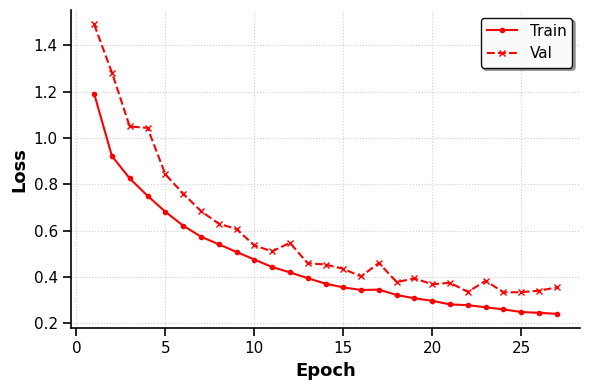

In [5]:
logs = {
    'fase1': """
Epoch [1/100] | Train Loss: 1.191655 | Val Loss: 1.490710
Epoch [2/100] | Train Loss: 0.921906 | Val Loss: 1.282964
Epoch [3/100] | Train Loss: 0.825236 | Val Loss: 1.049723
Epoch [4/100] | Train Loss: 0.750246 | Val Loss: 1.043703
Epoch [5/100] | Train Loss: 0.681573 | Val Loss: 0.843250
Epoch [6/100] | Train Loss: 0.621090 | Val Loss: 0.759959
Epoch [7/100] | Train Loss: 0.573820 | Val Loss: 0.684134
Epoch [8/100] | Train Loss: 0.540546 | Val Loss: 0.630091
Epoch [9/100] | Train Loss: 0.507561 | Val Loss: 0.605965
Epoch [10/100] | Train Loss: 0.474782 | Val Loss: 0.536175
Epoch [11/100] | Train Loss: 0.442503 | Val Loss: 0.509766
Epoch [12/100] | Train Loss: 0.419228 | Val Loss: 0.546974
Epoch [13/100] | Train Loss: 0.394135 | Val Loss: 0.458709
Epoch [14/100] | Train Loss: 0.370454 | Val Loss: 0.453028
Epoch [15/100] | Train Loss: 0.354486 | Val Loss: 0.434601
Epoch [16/100] | Train Loss: 0.343014 | Val Loss: 0.401510
Epoch [17/100] | Train Loss: 0.344684 | Val Loss: 0.460022
Epoch [18/100] | Train Loss: 0.321424 | Val Loss: 0.377228
Epoch [19/100] | Train Loss: 0.307238 | Val Loss: 0.393119
Epoch [20/100] | Train Loss: 0.296329 | Val Loss: 0.367876
Epoch [21/100] | Train Loss: 0.280764 | Val Loss: 0.374395
Epoch [22/100] | Train Loss: 0.277542 | Val Loss: 0.334812
Epoch [23/100] | Train Loss: 0.268377 | Val Loss: 0.383002
Epoch [24/100] | Train Loss: 0.259367 | Val Loss: 0.332751
Epoch [25/100] | Train Loss: 0.247957 | Val Loss: 0.333600
Epoch [26/100] | Train Loss: 0.244431 | Val Loss: 0.340206
Epoch [27/100] | Train Loss: 0.240282 | Val Loss: 0.353988
Early stopping triggered at epoch 27. Best Val Loss: 0.332751
"""
}

plot_training_results(logs, "latex/images/j8_convergence_a.png")

Plot saved to latex/images/j8_convergence_b.png


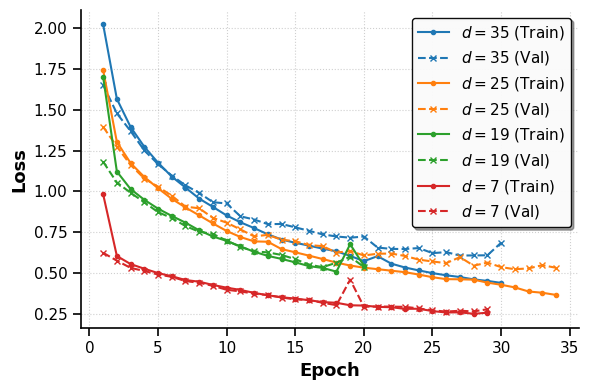

In [6]:
logs = {
35: """
Epoch [1/50] | Train Loss: 2.023152 | Val Loss: 1.651755
Epoch [2/50] | Train Loss: 1.566487 | Val Loss: 1.477679
Epoch [3/50] | Train Loss: 1.394281 | Val Loss: 1.369121
Epoch [4/50] | Train Loss: 1.272813 | Val Loss: 1.250464
Epoch [5/50] | Train Loss: 1.175293 | Val Loss: 1.166574
Epoch [6/50] | Train Loss: 1.089864 | Val Loss: 1.096208
Epoch [7/50] | Train Loss: 1.022713 | Val Loss: 1.036319
Epoch [8/50] | Train Loss: 0.954909 | Val Loss: 0.989752
Epoch [9/50] | Train Loss: 0.903840 | Val Loss: 0.932915
Epoch [10/50] | Train Loss: 0.851623 | Val Loss: 0.925145
Epoch [11/50] | Train Loss: 0.809742 | Val Loss: 0.846567
Epoch [12/50] | Train Loss: 0.774220 | Val Loss: 0.826693
Epoch [13/50] | Train Loss: 0.735698 | Val Loss: 0.798385
Epoch [14/50] | Train Loss: 0.704051 | Val Loss: 0.799311
Epoch [15/50] | Train Loss: 0.683889 | Val Loss: 0.778660
Epoch [16/50] | Train Loss: 0.666586 | Val Loss: 0.757424
Epoch [17/50] | Train Loss: 0.647959 | Val Loss: 0.735408
Epoch [18/50] | Train Loss: 0.631624 | Val Loss: 0.722724
Epoch [19/50] | Train Loss: 0.603471 | Val Loss: 0.715151
Epoch [20/50] | Train Loss: 0.571214 | Val Loss: 0.722302
Epoch [21/50] | Train Loss: 0.601952 | Val Loss: 0.654647
Epoch [22/50] | Train Loss: 0.555960 | Val Loss: 0.646366
Epoch [23/50] | Train Loss: 0.532224 | Val Loss: 0.645754
Epoch [24/50] | Train Loss: 0.514526 | Val Loss: 0.651539
Epoch [25/50] | Train Loss: 0.497860 | Val Loss: 0.620486
Epoch [26/50] | Train Loss: 0.484627 | Val Loss: 0.626664
Epoch [27/50] | Train Loss: 0.473902 | Val Loss: 0.605675
Epoch [28/50] | Train Loss: 0.459393 | Val Loss: 0.606424
Epoch [29/50] | Train Loss: 0.450118 | Val Loss: 0.607271
Epoch [30/50] | Train Loss: 0.437849 | Val Loss: 0.684283
""",
# 33: """
# Epoch [1/50] | Train Loss: 2.032743 | Val Loss: 1.636572
# Epoch [2/50] | Train Loss: 1.561472 | Val Loss: 1.470798
# Epoch [3/50] | Train Loss: 1.379606 | Val Loss: 1.329373
# Epoch [4/50] | Train Loss: 1.250098 | Val Loss: 1.210228
# Epoch [5/50] | Train Loss: 1.140123 | Val Loss: 1.118796
# Epoch [6/50] | Train Loss: 1.061274 | Val Loss: 1.059211
# Epoch [7/50] | Train Loss: 0.998199 | Val Loss: 1.013760
# Epoch [8/50] | Train Loss: 0.943991 | Val Loss: 0.966769
# Epoch [9/50] | Train Loss: 0.900020 | Val Loss: 0.920636
# Epoch [10/50] | Train Loss: 0.869576 | Val Loss: 0.904339
# Epoch [11/50] | Train Loss: 0.825473 | Val Loss: 0.876879
# Epoch [12/50] | Train Loss: 0.802210 | Val Loss: 0.852601
# Epoch [13/50] | Train Loss: 0.771407 | Val Loss: 0.788330
# Epoch [14/50] | Train Loss: 0.759633 | Val Loss: 0.795651
# Epoch [15/50] | Train Loss: 0.726489 | Val Loss: 0.774010
# Epoch [16/50] | Train Loss: 0.701576 | Val Loss: 0.757131
# Epoch [17/50] | Train Loss: 0.676112 | Val Loss: 0.732390
# Epoch [18/50] | Train Loss: 0.655784 | Val Loss: 0.689126
# Epoch [19/50] | Train Loss: 0.628246 | Val Loss: 0.691928
# Epoch [20/50] | Train Loss: 0.607122 | Val Loss: 0.723586
# Epoch [21/50] | Train Loss: 0.597152 | Val Loss: 0.708122
# """,
25: """
Epoch [1/50] | Train Loss: 1.743616 | Val Loss: 1.395015
Epoch [2/50] | Train Loss: 1.302440 | Val Loss: 1.273989
Epoch [3/50] | Train Loss: 1.172839 | Val Loss: 1.161507
Epoch [4/50] | Train Loss: 1.087481 | Val Loss: 1.078161
Epoch [5/50] | Train Loss: 1.018512 | Val Loss: 1.027620
Epoch [6/50] | Train Loss: 0.953739 | Val Loss: 0.972809
Epoch [7/50] | Train Loss: 0.900524 | Val Loss: 0.905569
Epoch [8/50] | Train Loss: 0.852222 | Val Loss: 0.895556
Epoch [9/50] | Train Loss: 0.802619 | Val Loss: 0.836624
Epoch [10/50] | Train Loss: 0.756373 | Val Loss: 0.807345
Epoch [11/50] | Train Loss: 0.719494 | Val Loss: 0.766071
Epoch [12/50] | Train Loss: 0.692487 | Val Loss: 0.723385
Epoch [13/50] | Train Loss: 0.690362 | Val Loss: 0.732409
Epoch [14/50] | Train Loss: 0.645183 | Val Loss: 0.702529
Epoch [15/50] | Train Loss: 0.625560 | Val Loss: 0.693627
Epoch [16/50] | Train Loss: 0.605136 | Val Loss: 0.669869
Epoch [17/50] | Train Loss: 0.584375 | Val Loss: 0.663351
Epoch [18/50] | Train Loss: 0.562345 | Val Loss: 0.623620
Epoch [19/50] | Train Loss: 0.544416 | Val Loss: 0.633423
Epoch [20/50] | Train Loss: 0.531317 | Val Loss: 0.606300
Epoch [21/50] | Train Loss: 0.522042 | Val Loss: 0.616749
Epoch [22/50] | Train Loss: 0.512809 | Val Loss: 0.617915
Epoch [23/50] | Train Loss: 0.503575 | Val Loss: 0.603051
Epoch [24/50] | Train Loss: 0.489072 | Val Loss: 0.580686
Epoch [25/50] | Train Loss: 0.472756 | Val Loss: 0.569234
Epoch [26/50] | Train Loss: 0.460938 | Val Loss: 0.559032
Epoch [27/50] | Train Loss: 0.459964 | Val Loss: 0.596088
Epoch [28/50] | Train Loss: 0.457730 | Val Loss: 0.543561
Epoch [29/50] | Train Loss: 0.439648 | Val Loss: 0.562184
Epoch [30/50] | Train Loss: 0.426437 | Val Loss: 0.534753
Epoch [31/50] | Train Loss: 0.410257 | Val Loss: 0.521726
Epoch [32/50] | Train Loss: 0.385259 | Val Loss: 0.526893
Epoch [33/50] | Train Loss: 0.377505 | Val Loss: 0.546532
Epoch [34/50] | Train Loss: 0.364137 | Val Loss: 0.530761
""",
# 23:"""
# Epoch [1/50] | Train Loss: 1.608027 | Val Loss: 1.286605
# Epoch [2/50] | Train Loss: 1.221455 | Val Loss: 1.165591
# Epoch [3/50] | Train Loss: 1.113299 | Val Loss: 1.057217
# Epoch [4/50] | Train Loss: 1.037356 | Val Loss: 1.002363
# Epoch [5/50] | Train Loss: 0.964433 | Val Loss: 0.939658
# Epoch [6/50] | Train Loss: 0.894588 | Val Loss: 0.886952
# Epoch [7/50] | Train Loss: 0.830555 | Val Loss: 0.834662
# Epoch [8/50] | Train Loss: 0.777108 | Val Loss: 0.805975
# Epoch [9/50] | Train Loss: 0.725473 | Val Loss: 0.764447
# Epoch [10/50] | Train Loss: 0.693118 | Val Loss: 0.737365
# Epoch [11/50] | Train Loss: 0.654776 | Val Loss: 0.739323
# Epoch [12/50] | Train Loss: 0.624555 | Val Loss: 0.730333
# Epoch [13/50] | Train Loss: 0.594128 | Val Loss: 0.713307
# Epoch [14/50] | Train Loss: 0.564044 | Val Loss: 0.666438
# Epoch [15/50] | Train Loss: 0.546224 | Val Loss: 0.679986
# Epoch [16/50] | Train Loss: 0.519883 | Val Loss: 0.632857
# Epoch [17/50] | Train Loss: 0.497027 | Val Loss: 0.646216
# Epoch [18/50] | Train Loss: 0.481385 | Val Loss: 0.618088
# Epoch [19/50] | Train Loss: 0.462670 | Val Loss: 0.607362
# Epoch [20/50] | Train Loss: 0.444937 | Val Loss: 0.573788
# Epoch [21/50] | Train Loss: 0.432910 | Val Loss: 0.565275
# Epoch [22/50] | Train Loss: 0.419105 | Val Loss: 0.558899
# Epoch [23/50] | Train Loss: 0.405615 | Val Loss: 0.550503
# Epoch [24/50] | Train Loss: 0.394479 | Val Loss: 0.527201
# Epoch [25/50] | Train Loss: 0.382999 | Val Loss: 0.629049
# Epoch [26/50] | Train Loss: 0.384341 | Val Loss: 0.568601
# Epoch [27/50] | Train Loss: 0.369081 | Val Loss: 0.540698
# """,
19:"""
Epoch [1/50] | Train Loss: 1.701958 | Val Loss: 1.180999
Epoch [2/50] | Train Loss: 1.120952 | Val Loss: 1.053561
Epoch [3/50] | Train Loss: 1.013569 | Val Loss: 0.990936
Epoch [4/50] | Train Loss: 0.947665 | Val Loss: 0.932202
Epoch [5/50] | Train Loss: 0.893211 | Val Loss: 0.871985
Epoch [6/50] | Train Loss: 0.848754 | Val Loss: 0.835676
Epoch [7/50] | Train Loss: 0.807356 | Val Loss: 0.786647
Epoch [8/50] | Train Loss: 0.760212 | Val Loss: 0.751724
Epoch [9/50] | Train Loss: 0.722654 | Val Loss: 0.738475
Epoch [10/50] | Train Loss: 0.695497 | Val Loss: 0.697076
Epoch [11/50] | Train Loss: 0.661673 | Val Loss: 0.659330
Epoch [12/50] | Train Loss: 0.629045 | Val Loss: 0.631259
Epoch [13/50] | Train Loss: 0.603685 | Val Loss: 0.624989
Epoch [14/50] | Train Loss: 0.584954 | Val Loss: 0.609472
Epoch [15/50] | Train Loss: 0.563880 | Val Loss: 0.583368
Epoch [16/50] | Train Loss: 0.540985 | Val Loss: 0.549768
Epoch [17/50] | Train Loss: 0.529526 | Val Loss: 0.534468
Epoch [18/50] | Train Loss: 0.507022 | Val Loss: 0.561845
Epoch [19/50] | Train Loss: 0.675171 | Val Loss: 0.598100
Epoch [20/50] | Train Loss: 0.543257 | Val Loss: 0.535306
""",
# 13: """
# Epoch [1/50] | Train Loss: 1.269257 | Val Loss: 0.867169
# Epoch [2/50] | Train Loss: 0.858501 | Val Loss: 0.800177
# Epoch [3/50] | Train Loss: 0.799278 | Val Loss: 0.745973
# Epoch [4/50] | Train Loss: 0.748040 | Val Loss: 0.714792
# Epoch [5/50] | Train Loss: 0.702281 | Val Loss: 0.670148
# Epoch [6/50] | Train Loss: 0.658172 | Val Loss: 0.631283
# Epoch [7/50] | Train Loss: 0.615216 | Val Loss: 0.589219
# Epoch [8/50] | Train Loss: 0.570725 | Val Loss: 0.614282
# Epoch [9/50] | Train Loss: 0.537721 | Val Loss: 0.577373
# Epoch [10/50] | Train Loss: 0.508036 | Val Loss: 0.536592
# Epoch [11/50] | Train Loss: 0.477899 | Val Loss: 0.495432
# Epoch [12/50] | Train Loss: 0.455310 | Val Loss: 0.533676
# Epoch [13/50] | Train Loss: 0.428155 | Val Loss: 0.482814
# Epoch [14/50] | Train Loss: 0.415471 | Val Loss: 0.519635
# Epoch [15/50] | Train Loss: 0.392525 | Val Loss: 0.506770
# Epoch [16/50] | Train Loss: 0.375720 | Val Loss: 0.479560
# Epoch [17/50] | Train Loss: 0.359700 | Val Loss: 0.466442
# Epoch [18/50] | Train Loss: 0.343274 | Val Loss: 0.444882
# Epoch [19/50] | Train Loss: 0.329844 | Val Loss: 0.436194
# Epoch [20/50] | Train Loss: 0.316486 | Val Loss: 0.427183
# Epoch [21/50] | Train Loss: 0.306088 | Val Loss: 0.428526
# Epoch [22/50] | Train Loss: 0.294722 | Val Loss: 0.417903
# Epoch [23/50] | Train Loss: 0.285485 | Val Loss: 0.408648
# Epoch [24/50] | Train Loss: 0.275715 | Val Loss: 0.398620
# Epoch [25/50] | Train Loss: 0.268174 | Val Loss: 0.394303
# Epoch [26/50] | Train Loss: 0.264870 | Val Loss: 0.373115
# Epoch [27/50] | Train Loss: 0.263394 | Val Loss: 0.386330
# Epoch [28/50] | Train Loss: 0.251561 | Val Loss: 0.366382
# Epoch [29/50] | Train Loss: 0.240856 | Val Loss: 0.376803
# Epoch [30/50] | Train Loss: 0.234317 | Val Loss: 0.355716
# Epoch [31/50] | Train Loss: 0.232442 | Val Loss: 0.400040
# Epoch [32/50] | Train Loss: 0.224485 | Val Loss: 0.363800
# Epoch [33/50] | Train Loss: 0.218687 | Val Loss: 0.348331
# Epoch [34/50] | Train Loss: 0.212117 | Val Loss: 0.398896
# Epoch [35/50] | Train Loss: 0.207931 | Val Loss: 0.351239
# Epoch [36/50] | Train Loss: 0.200717 | Val Loss: 0.344952
# Epoch [37/50] | Train Loss: 0.200956 | Val Loss: 0.357003
# Epoch [38/50] | Train Loss: 0.345444 | Val Loss: 0.411851
# Epoch [39/50] | Train Loss: 0.216966 | Val Loss: 0.379229
# """,
7: """
Epoch [1/50] | Train Loss: 0.981601 | Val Loss: 0.622592
Epoch [2/50] | Train Loss: 0.602986 | Val Loss: 0.574138
Epoch [3/50] | Train Loss: 0.553435 | Val Loss: 0.530020
Epoch [4/50] | Train Loss: 0.524849 | Val Loss: 0.510880
Epoch [5/50] | Train Loss: 0.498012 | Val Loss: 0.489208
Epoch [6/50] | Train Loss: 0.478969 | Val Loss: 0.475099
Epoch [7/50] | Train Loss: 0.455308 | Val Loss: 0.449260
Epoch [8/50] | Train Loss: 0.445218 | Val Loss: 0.438442
Epoch [9/50] | Train Loss: 0.425282 | Val Loss: 0.420175
Epoch [10/50] | Train Loss: 0.408554 | Val Loss: 0.395715
Epoch [11/50] | Train Loss: 0.394956 | Val Loss: 0.385612
Epoch [12/50] | Train Loss: 0.376672 | Val Loss: 0.371721
Epoch [13/50] | Train Loss: 0.362069 | Val Loss: 0.363257
Epoch [14/50] | Train Loss: 0.349669 | Val Loss: 0.348327
Epoch [15/50] | Train Loss: 0.341861 | Val Loss: 0.336721
Epoch [16/50] | Train Loss: 0.331597 | Val Loss: 0.333133
Epoch [17/50] | Train Loss: 0.320027 | Val Loss: 0.315907
Epoch [18/50] | Train Loss: 0.315952 | Val Loss: 0.301372
Epoch [19/50] | Train Loss: 0.300532 | Val Loss: 0.457747
Epoch [20/50] | Train Loss: 0.298873 | Val Loss: 0.291724
Epoch [21/50] | Train Loss: 0.290852 | Val Loss: 0.292994
Epoch [22/50] | Train Loss: 0.288696 | Val Loss: 0.292443
Epoch [23/50] | Train Loss: 0.278554 | Val Loss: 0.290926
Epoch [24/50] | Train Loss: 0.279424 | Val Loss: 0.281350
Epoch [25/50] | Train Loss: 0.264924 | Val Loss: 0.269479
Epoch [26/50] | Train Loss: 0.256430 | Val Loss: 0.262010
Epoch [27/50] | Train Loss: 0.257319 | Val Loss: 0.267081
Epoch [28/50] | Train Loss: 0.248441 | Val Loss: 0.262869
Epoch [29/50] | Train Loss: 0.255062 | Val Loss: 0.276404
"""
}

plot_training_results(logs, "latex/images/j8_convergence_b.png")